# 05 Exotic options

European options have closed-form Black-Scholes solutions; exotic options do not. We then must use Monte Carlo in order to price them. <br>
We implement two common exotics:
- **Asian options**: payoff based on the average price over the path; even if the price finishes below the strike price, it can still pay off if the average price is above the strike price
- **Barrier options**: expires worthless if the stock ever crosses a barrier over the path; even if the stock recovers, the option can not be exercised

The simulation is identical to before with changes only being made to the payoff function.

In [1]:
import sys
sys.path.append('../src')

import numpy as np
import matplotlib.pyplot as plt
from gbm import simulate_paths
from pricer import bs_pricing

In [2]:
Sof0  = 100
K     = 105
r     = 0.05
sigma = 0.20
T     = 1.0
N     = int(252 * T)
M     = 1000

paths = simulate_paths(Sof0, r, sigma, T, N, M, seed=42)
final = paths[-1, :]
time  = np.linspace(0, T, N + 1)

## On Asian options

A standard European call pays $\max(S_T - K, 0)$, and it only cares about the final price. An Asian call pays $\max(S_{avg} - K, 0)$, where $S_{avg}$ is the arithmetic mean of the stock price over the entire path.

Asian options are therefore:
- Cheaper than European options as the average is less volatile than the final price
- Harder to manipulate as you can't move the price on a single day to affect the payoff

In [3]:
# arithmetic average of each path (exclude t=0)
average_prices = paths[1:, :].mean(axis=0)
asian_payoffs  = np.maximum(average_prices - K, 0)
asian_price    = np.exp(-r * T) * asian_payoffs.mean()

# European price for comparison
european_payoffs = np.maximum(final - K, 0)
european_price   = np.exp(-r * T) * european_payoffs.mean()
bs_price         = bs_pricing(Sof0, K, r, sigma, T, option_type='call')

print(f"Asian call price    : ${asian_price:.4f}")
print(f"European call price : ${european_price:.4f}")
print(f"Black-Scholes price : ${bs_price:.4f}")
print(f"Asian discount      : ${european_price - asian_price:.4f}")

Asian call price    : $3.5824
European call price : $8.2280
Black-Scholes price : $8.0214
Asian discount      : $4.6456


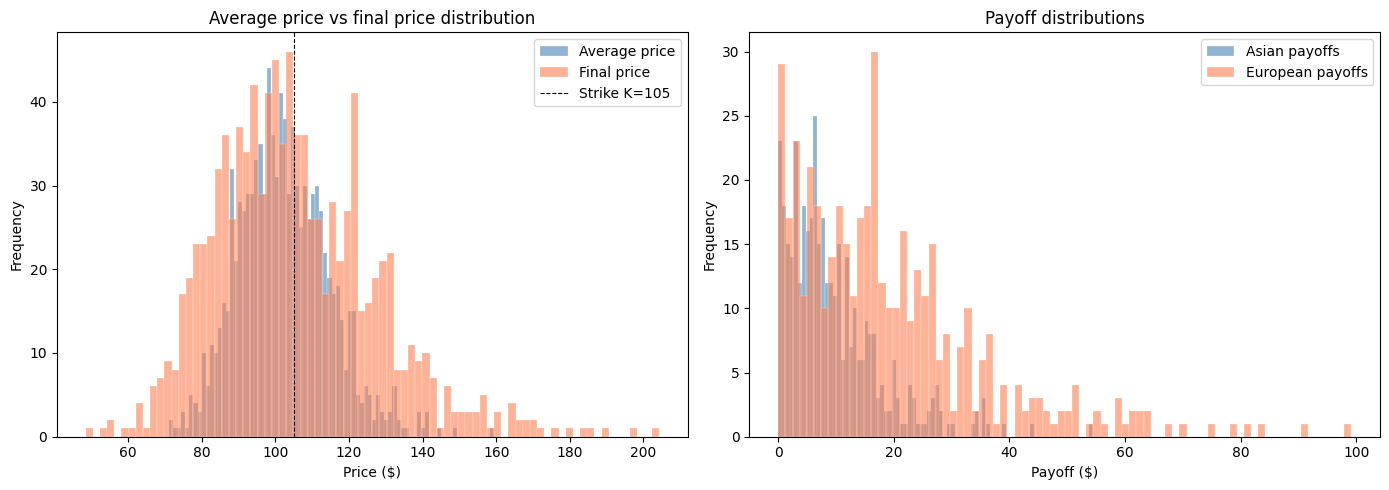

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# distribution of average prices vs final prices
axes[0].hist(average_prices, bins=80, alpha=0.6, color='steelblue',
             label='Average price', edgecolor='white', linewidth=0.3)
axes[0].hist(final, bins=80, alpha=0.6, color='coral',
             label='Final price', edgecolor='white', linewidth=0.3)
axes[0].axvline(K, color='black', linestyle='--', linewidth=0.8, label=f'Strike K={K}')
axes[0].set_xlabel('Price ($)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Average price vs final price distribution')
axes[0].legend()

# payoff distributions
axes[1].hist(asian_payoffs[asian_payoffs > 0], bins=80, alpha=0.6,
             color='steelblue', label='Asian payoffs', edgecolor='white', linewidth=0.3)
axes[1].hist(european_payoffs[european_payoffs > 0], bins=80, alpha=0.6,
             color='coral', label='European payoffs', edgecolor='white', linewidth=0.3)
axes[1].set_xlabel('Payoff ($)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Payoff distributions')
axes[1].legend()

plt.tight_layout()
plt.show()

## On barrier options

A knock-out barrier option is a European call that will expire worthless if the stock ever touches or crosses a barrier level $B$ during its life. If the stock hits the barrier, the option will pay nothing, regardless of if it later recovers. The risk leads to a lower premium, making barrier options cheaper than regular European options.

In [5]:
barrier = 130  # knock-out level

# check if each path ever touched or crossed the barrier
knocked_out = paths.max(axis=0) >= barrier

# payoff: standard call payoff, zeroed out for knocked-out paths
barrier_payoffs = np.maximum(final - K, 0) * ~knocked_out
barrier_price   = np.exp(-r * T) * barrier_payoffs.mean()

pct_knocked_out = knocked_out.mean() * 100

print(f"Barrier call price  : ${barrier_price:.4f}")
print(f"European call price : ${european_price:.4f}")
print(f"Paths knocked out   : {pct_knocked_out:.1f}%")
print(f"Barrier discount    : ${european_price - barrier_price:.4f}")

Barrier call price  : $2.2605
European call price : $8.2280
Paths knocked out   : 21.1%
Barrier discount    : $5.9675


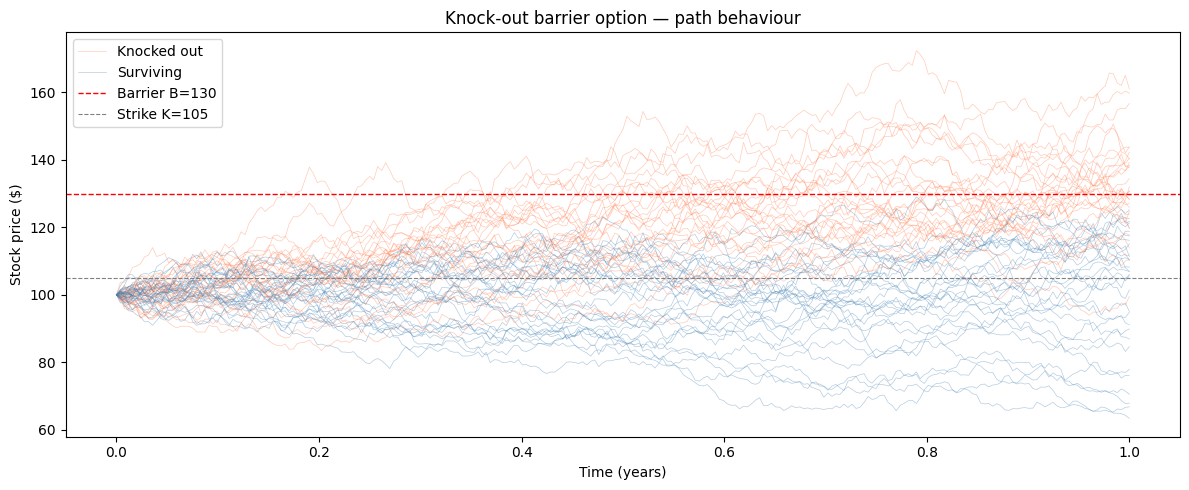

In [7]:
# visualise some knocked-out vs surviving paths
knocked_out_idx = np.where(knocked_out)[0][:30]
surviving_idx   = np.where(~knocked_out)[0][:30]

plt.figure(figsize=(12, 5))

plt.plot(time, paths[:, knocked_out_idx[0]], color='coral',
         linewidth=0.5, alpha=0.4, label='Knocked out')
plt.plot(time, paths[:, knocked_out_idx[1:]], color='coral',
         linewidth=0.5, alpha=0.4)

plt.plot(time, paths[:, surviving_idx[0]], color='steelblue',
         linewidth=0.5, alpha=0.4, label='Surviving')
plt.plot(time, paths[:, surviving_idx[1:]], color='steelblue',
         linewidth=0.5, alpha=0.4)

plt.axhline(barrier, color='red', linestyle='--', linewidth=1.0, label=f'Barrier B={barrier}')
plt.axhline(K, color='gray', linestyle='--', linewidth=0.8, label=f'Strike K={K}')
plt.xlabel('Time (years)')
plt.ylabel('Stock price ($)')
plt.title('Knock-out barrier option — path behaviour')
plt.legend()
plt.tight_layout()
plt.show()

## On barrier sensitivity

A higher barrier will of course knock out fewer paths, and the price of the option approaches the European option price as B approaches $\infty$, basically because a higher barrier will lead to a lower probability that the option can not be exercised.

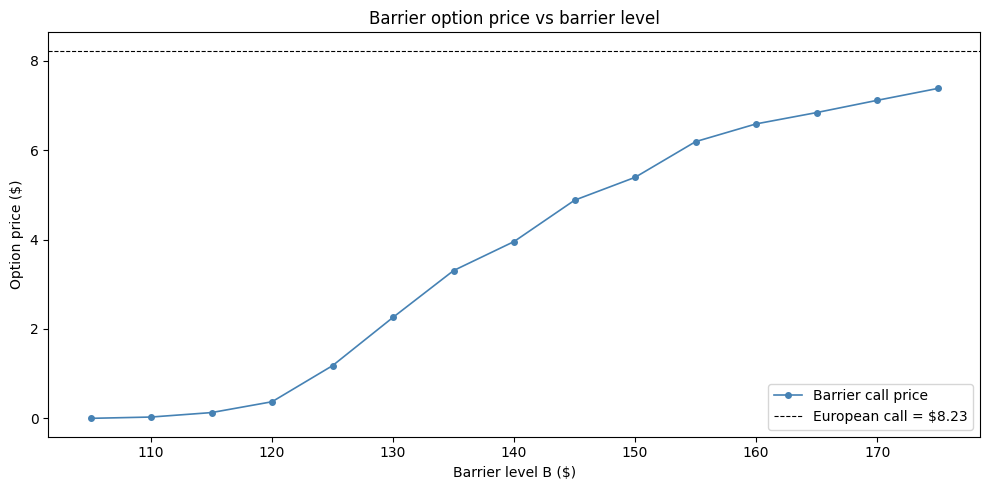

In [8]:
barriers      = np.arange(105, 180, 5)
barrier_prices = []

for B in barriers:
    ko          = paths.max(axis=0) >= B
    payoffs_b   = np.maximum(final - K, 0) * ~ko
    barrier_prices.append(np.exp(-r * T) * payoffs_b.mean())

plt.figure(figsize=(10, 5))
plt.plot(barriers, barrier_prices, color='steelblue', linewidth=1.2,
         marker='o', markersize=4, label='Barrier call price')
plt.axhline(european_price, color='black', linestyle='--',
            linewidth=0.8, label=f'European call = ${european_price:.2f}')
plt.xlabel('Barrier level B ($)')
plt.ylabel('Option price ($)')
plt.title('Barrier option price vs barrier level')
plt.legend()
plt.tight_layout()
plt.show()